# Cross-validation

In this exercise, we use resampling methods to evaluate the predictive performance of polynomial regression models.

We first use the validation set approach and then compare it with K-fold cross-validation.

### 1.Load the data

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold, cross_val_score

# Load the pollution data
pollution = pd.read_csv("pollution_cleaneddata.csv")

# Display the first few rows
pollution.head()

pollution.columns

pollution.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PREC    60 non-null     float64
 1   JANT    60 non-null     float64
 2   JULT    60 non-null     float64
 3   OVR65   60 non-null     float64
 4   POPN    60 non-null     float64
 5   EDUC    60 non-null     float64
 6   HOUS    60 non-null     float64
 7   DENS    60 non-null     float64
 8   NONW    60 non-null     float64
 9   WWDRK   60 non-null     float64
 10  POOR    60 non-null     float64
 11  HC      60 non-null     float64
 12  NOX     60 non-null     float64
 13  SO@     60 non-null     float64
 14  HUMID   60 non-null     float64
 15  MORT    60 non-null     float64
dtypes: float64(16)
memory usage: 7.6 KB


### 2.Polynomial regression model

Model mortality (`MORT`) as a polynomial function of the average July temperature (`JULT`) in degrees Fahrenheit.

For a polynomial of degree `p`, the model is:

$MORT = \beta_0 + \beta_1 JULT + \beta_2 JULT^2 + \cdots + \beta_p JULT^p + \epsilon$

Here, `p` is the degree of the polynomial. We will later compare models with degrees `p = 1, 2, 3, 4`.

In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Predictor and response
X = pollution[["JULT"]]
y = pollution["MORT"]

# Polynomial degree
p = 2

# Create polynomial features
poly = PolynomialFeatures(degree=p)
X_poly = poly.fit_transform(X)

# Fit the polynomial regression model
model = LinearRegression()
model.fit(X_poly, y)

print(f"Polynomial regression model with degree p = {p} fitted.")

Polynomial regression model with degree p = 2 fitted.


### 3. Set the random seed

set a random seed to make the random split reproducible.

In [7]:
import numpy as np

seed = 123
np.random.seed(seed)

### 4. Split the data into training and testing sets

Split the data into two equal-sized sets: one for training and one for testing.

Since the dataset contains 60 observations, each set contains 30 observations.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=seed
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 30
Testing observations: 30


### 5. Compare polynomial models

Fit polynomial regression models with degrees \(p = 1, 2, 3, 4\).

For each model, we calculate the mean squared error (MSE) for both the training and testing data:

$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2$

The training and testing MSE are then plotted against the polynomial degree.

   degree  training_MSE  testing_MSE
0       1   2866.993299  4703.889138
1       2   2851.748712  4413.295764
2       3   2828.724250  4286.228553
3       4   2793.821711  4169.294755


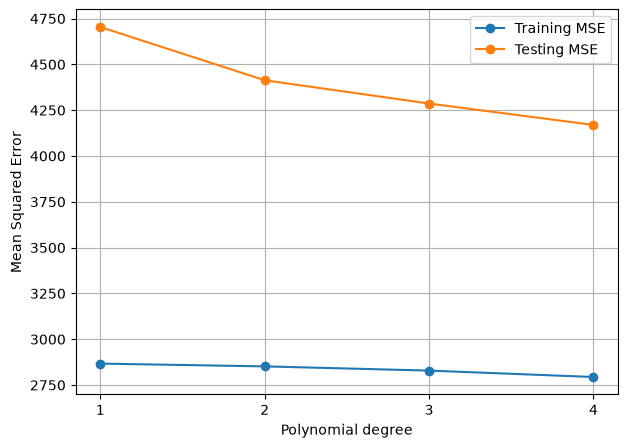

In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

results = []

for p in range(1, 5):
    # Create polynomial features
    poly = PolynomialFeatures(degree=p)
    
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    # Fit the model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    # Calculate MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    results.append({
        "degree": p,
        "training_MSE": train_mse,
        "testing_MSE": test_mse
    })

results_df = pd.DataFrame(results)

print(results_df)

# Plot MSE against polynomial degree
plt.figure(figsize=(7, 5))

plt.plot(
    results_df["degree"],
    results_df["training_MSE"],
    marker="o",
    label="Training MSE"
)

plt.plot(
    results_df["degree"],
    results_df["testing_MSE"],
    marker="o",
    label="Testing MSE"
)

plt.xlabel("Polynomial degree")
plt.ylabel("Mean Squared Error")
plt.xticks([1, 2, 3, 4])
plt.legend()
plt.grid(True)

plt.show()

### 6.Choice of polynomial degree

Based on the plot, I would recommend a polynomial of degree 4.

Among the four models, the degree-4 polynomial has the lowest testing MSE (4169.29), indicating the smallest prediction error on the testing data for this particular train-test split.

### 7.Repeat the validation set approach with different random seeds

To investigate how sensitive the results are to the particular train-test split, we can repeat the procedure ten times using different random seeds.

For each seed, calculate the testing MSE for polynomial degrees 1 to 4 and compare the results.

    seed  degree  testing_MSE
0      0       1  3202.000744
1      0       2  2874.583869
2      0       3  2821.110660
3      0       4  2765.436687
4      1       1  5040.756601
5      1       2  6264.876170
6      1       3  5848.947351
7      1       4  5506.432933
8      2       1  3478.233759
9      2       2  6425.207260
10     2       3  5915.792389
11     2       4  5462.582389
12     3       1  3667.911949
13     3       2  3508.538872
14     3       3  3462.713780
15     3       4  3412.668122
16     4       1  4017.191740
17     4       2  4456.842315
18     4       3  4442.716460
19     4       4  4410.195439
20     5       1  2563.018524
21     5       2  2407.977929
22     5       3  2374.796451
23     5       4  2339.727446
24     6       1  3747.668835
25     6       2  4266.916605
26     6       3  3992.860150
27     6       4  3751.892741
28     7       1  5080.687024
29     7       2  4513.812841
30     7       3  4399.977250
31     7       4  4286.596426
32     8  

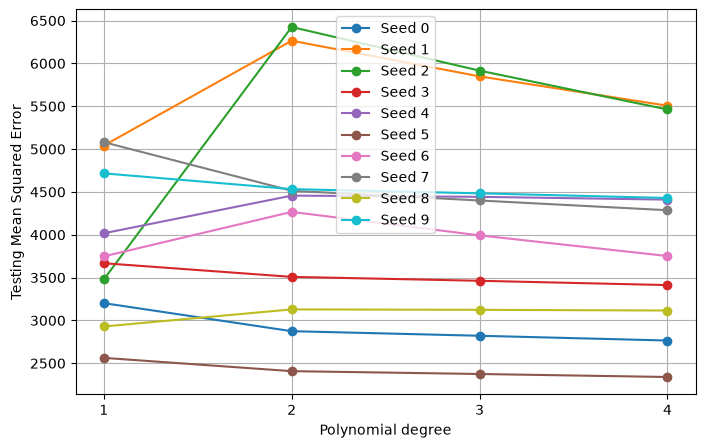

In [11]:
seeds = range(10)

all_results = []

for seed in seeds:
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.5,
        random_state=seed
    )
    
    # Fit polynomial models with degrees 1 to 4
    for p in range(1, 5):
        poly = PolynomialFeatures(degree=p)
        
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)
        
        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        
        y_test_pred = model.predict(X_test_poly)
        
        test_mse = mean_squared_error(y_test, y_test_pred)
        
        all_results.append({
            "seed": seed,
            "degree": p,
            "testing_MSE": test_mse
        })

all_results_df = pd.DataFrame(all_results)

print(all_results_df)

plt.figure(figsize=(8, 5))

for seed in seeds:
    subset = all_results_df[all_results_df["seed"] == seed]
    
    plt.plot(
        subset["degree"],
        subset["testing_MSE"],
        marker="o",
        label=f"Seed {seed}"
    )

plt.xlabel("Polynomial degree")
plt.ylabel("Testing Mean Squared Error")
plt.xticks([1, 2, 3, 4])
plt.legend()
plt.grid(True)

plt.show()

### Results for different random seeds

The results are not completely consistent across the ten random seeds.

For some seeds, the degree-4 polynomial has the lowest testing MSE, while for other seeds, the degree-1 polynomial has the lowest testing MSE. In particular, degree 4 gives the lowest testing MSE for 6 out of 10 seeds, while degree 1 gives the lowest testing MSE for 4 out of 10 seeds.

This shows that the validation set approach is sensitive to the particular random train-test split. Therefore, the choice of polynomial degree based on a single split may not be very stable.

### 8. K-fold cross-validation

Select a polynomial regression model with degree \(p=2\).

Using 3-fold cross-validation, we can divide the data into three folds. In each iteration, one fold is held out as the validation set and the remaining two folds are used to fit the model.

For each fold, we can calculate the mean squared error (MSE) of the predictions. We then calculate the mean and variance of the three fold-specific MSE values.

In [16]:
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

p = 2
K = 3
seed = 123

kf = KFold(
    n_splits=K,
    shuffle=True,
    random_state=seed
)

fold_mse = []

for train_index, test_index in kf.split(X):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    model = make_pipeline(
        PolynomialFeatures(degree=p),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    fold_mse.append(mse)

mean_mse = np.mean(fold_mse)
variance_mse = np.var(fold_mse, ddof=1)

print("MSE for each fold:", fold_mse)
print("Mean CV MSE:", mean_mse)
print("Variance of fold MSE:", variance_mse)

MSE for each fold: [5565.847931776224, 2955.052532486888, 5269.557366757623]
Mean CV MSE: 4596.819277006912
Variance of fold MSE: 2043495.5572886677


### 9.Repeat K-fold cross-validation with different random seeds

Repeat the 3-fold cross-validation procedure ten times using different random seeds.

For each seed, we calculate the variance of the cross-validated predictions and compare the results.

Since K-fold cross-validation uses all observations for both training and validation across the folds, the result is expected to be less dependent on one particular train-test split than the validation set approach.

In [17]:
cv_results = []

for seed in range(10):
    kf = KFold(
        n_splits=3,
        shuffle=True,
        random_state=seed
    )

    fold_mse = []

    for train_index, test_index in kf.split(X):
        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        model = make_pipeline(
            PolynomialFeatures(degree=2),
            LinearRegression()
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        fold_mse.append(mse)

    mean_mse = np.mean(fold_mse)
    variance_mse = np.var(fold_mse, ddof=1)

    cv_results.append({
        "seed": seed,
        "mean_MSE": mean_mse,
        "variance_MSE": variance_mse
    })

cv_results_df = pd.DataFrame(cv_results)

print(cv_results_df)

   seed     mean_MSE  variance_MSE
0     0  4049.489437  1.782224e+06
1     1  5175.994078  4.977409e+06
2     2  5176.310229  8.728803e+06
3     3  3513.029877  3.613457e+06
4     4  3826.803794  1.312580e+06
5     5  3924.199874  6.476729e+06
6     6  5740.597705  2.605720e+06
7     7  3758.749369  3.505452e+05
8     8  3576.517064  1.458735e+06
9     9  5723.806750  1.125033e+07


### Results for different random seeds

Repeating the 3-fold cross-validation with different random seeds gives somewhat different results. The mean MSE ranges from approximately 3513 to 5741, so the overall prediction error remains in the same general range but is not identical across different seeds.

The variance of the fold-specific MSE values varies much more strongly, ranging from approximately 3.5 × 10^5 to 1.13 × 10^7.

Therefore, the results are not completely stable across different random seeds. This is because changing the random seed changes how the observations are divided into the three folds. Since the dataset is relatively small, different folds can contain different observations and therefore have different prediction errors.



### 10.load the bird data

In [18]:
import pandas as pd

birds = pd.read_csv("bird_count.csv")

birds.head()
birds.info()

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   count        13 non-null     int64  
 1   yr           13 non-null     int64  
 2   observerAge  13 non-null     int64  
 3   lineCov      13 non-null     float64
dtypes: float64(1), int64(3)
memory usage: 548.0 bytes


### 11.Retrieve the Poisson model fitted with maximum likelihood that we did earlier in the course.

In [19]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import gammaln

# Read the data
data = pd.read_csv("bird_count.csv")

year = data["yr"].values
count = data["count"].values

# Center the year variable
year_c = year - np.mean(year)

# Define the negative log-likelihood
#
# Model:
# Y_i ~ Poisson(lambda_i)
# log(lambda_i) = beta0 + beta1 * year_c

def neg_log_likelihood(beta, year, count):
    beta0, beta1 = beta
    
    lam = np.exp(beta0 + beta1 * year)
    
    log_likelihood = np.sum(
        count * np.log(lam)
        - lam
        - gammaln(count + 1)
    )
    
    return -log_likelihood

# Estimate parameters using maximum likelihood
initial_beta = np.array([1.0, 0.0])

result = minimize(
    neg_log_likelihood,
    initial_beta,
    args=(year_c, count)
)

print("Optimization successful:", result.success)

beta0, beta1 = result.x

print("Estimated parameters:")
print("beta0 =", beta0)
print("beta1 =", beta1)

Optimization successful: True
Estimated parameters:
beta0 = 2.1082121961214266
beta1 = -0.03244316557337736


### 12.Bootstrap standard error

Use non-parametric bootstrap resampling to estimate the standard error of the slope parameter.

For each bootstrap sample, 13 observations are sampled with replacement from the original data. The year variable is centered using the mean year of the bootstrap sample, and the Poisson regression model is fitted again using maximum likelihood.

This procedure is repeated 10,000 times. The standard deviation of the 10,000 bootstrap estimates of the slope parameter is used as the bootstrap estimate of its standard error.


In [20]:
# Bootstrap estimation of the standard error of beta1

B = 10000
bootstrap_beta1 = []

rng = np.random.default_rng(123)

for _ in range(B):
    
    # Resample observations with replacement
    indices = rng.choice(len(data), size=len(data), replace=True)
    
    year_boot = year[indices]
    count_boot = count[indices]
    
    # Center the bootstrap year variable
    year_boot_c = year_boot - np.mean(year_boot)
    
    # Fit the Poisson model to the bootstrap sample
    result_boot = minimize(
        neg_log_likelihood,
        initial_beta,
        args=(year_boot_c, count_boot)
    )
    
    beta0_boot, beta1_boot = result_boot.x
    
    bootstrap_beta1.append(beta1_boot)

bootstrap_beta1 = np.array(bootstrap_beta1)

# Bootstrap standard error
bootstrap_se = np.std(bootstrap_beta1, ddof=1)

print("Original slope estimate:", beta1)
print("Bootstrap standard error:", bootstrap_se)

Original slope estimate: -0.03244316557337736
Bootstrap standard error: 0.033848133084776896


### Summary

The maximum likelihood estimate of the slope was **-0.03244**. Using 10,000 bootstrap samples, the standard deviation of the bootstrap slope estimates was **0.03385**.

This is close to the reference value of **0.03421**, with the small difference arising from the random bootstrap resampling.
